# Juego Predictivo Mundial 2026 — Modelo Elo + Simulación Monte Carlo


## ¿Qué hace este notebook?

Este notebook predice qué selecciones llegarán a cada fase del Mundial 2026 usando dos modelos estadísticos combinados:

1. **Ranking Elo**: asigna una fuerza numérica a cada selección. A partir de la diferencia de Elo entre dos equipos se calcula la probabilidad de que uno le gane al otro (la misma fórmula que se usa en ajedrez).
2. **Simulación Monte Carlo**: en lugar de "adivinar" un resultado, simula el torneo COMPLETO miles de veces. En cada simulación los partidos se deciden al azar según las probabilidades Elo. Al final contamos cuántas veces llegó cada equipo a octavos, cuartos, semis, final y campeón.

**Idea clave:** una predicción no es una certeza, es una estimación. Por eso decimos "Argentina llega a la final el 64% de las veces", no "Argentina va a la final".

Datos usados:
- Ratings Elo actualizados a **16 de junio de 2026** (eloratings.net / footballratings.org).
- Los **12 grupos reales** del sorteo del 5 de diciembre de 2025.
- Formato real 2026: 48 equipos, 12 grupos, avanzan los 2 primeros de cada grupo + los 8 mejores terceros (Ronda de 32).

## Celda 1 — Importar librerías

`numpy` para los cálculos numéricos, `pandas` para las tablas, `random` para el azar de las simulaciones, `collections` para contar resultados.

In [ ]:
import numpy as np
import pandas as pd
import random
from collections import defaultdict
import matplotlib.pyplot as plt

# Semilla para que los resultados sean reproducibles (siempre den lo mismo al volver a correr)
random.seed(42)
np.random.seed(42)

print("Librerías cargadas correctamente ")

Librerías cargadas correctamente ✅


## Celda 2 — Ratings Elo de las 48 selecciones

Estos son los ratings Elo de cada selección clasificada, actualizados a junio de 2026. Un Elo más alto = selección más fuerte. Como referencia: por encima de 2000 son los súper favoritos (España, Argentina, Francia), y alrededor de 1500-1600 están las selecciones más débiles del torneo.

In [3]:
# Diccionario: nombre de la selección -> rating Elo (junio 2026)
elo = {
    # Súper favoritos
    'España': 2129,
    'Argentina': 2115,
    'Francia': 2063,
    'Inglaterra': 2024,
    'Portugal': 1989,
    'Colombia': 1982,
    'Brasil': 1978,
    'Países Bajos': 1959,
    'Croacia': 1933,
    'Ecuador': 1933,
    'Noruega': 1922,
    'Alemania': 1910,
    'Suiza': 1897,
    'Uruguay': 1890,
    'Turquía': 1880,
    'Japón': 1879,
    'Senegal': 1869,
    'Bélgica': 1849,
    'Marruecos': 1840,
    'México': 1830,
    'Estados Unidos': 1808,
    'Austria': 1795,
    'Suecia': 1790,
    'Egipto': 1785,
    'Australia': 1770,
    'Irán': 1760,
    'Corea del Sur': 1755,
    'Costa de Marfil': 1745,
    'Paraguay': 1730,
    'Escocia': 1720,
    'Argelia': 1715,
    'Canadá': 1705,
    'Túnez': 1695,
    'Nigeria': 1690,  # nota: no clasificó, se deja fuera abajo
    'Catar': 1680,
    'Arabia Saudita': 1670,
    'Panamá': 1660,
    'Ghana': 1655,
    'Bosnia y Herzegovina': 1650,
    'Uzbekistán': 1640,
    'RD Congo': 1635,
    'Sudáfrica': 1625,
    'Jordania': 1610,
    'República Checa': 1605,
    'Cabo Verde': 1560,
    'Nueva Zelanda': 1540,
    'Irak': 1525,
    'Haití': 1490,
    'Curazao': 1470,
}

print(f"Selecciones cargadas: {len(elo)}")
# Mostrar el top 10 por Elo
top10 = sorted(elo.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 por Elo:")
for i, (team, rating) in enumerate(top10, 1):
    print(f"{i:2d}. {team:20s} {rating}")

Selecciones cargadas: 49

Top 10 por Elo:
 1. España               2129
 2. Argentina            2115
 3. Francia              2063
 4. Inglaterra           2024
 5. Portugal             1989
 6. Colombia             1982
 7. Brasil               1978
 8. Países Bajos         1959
 9. Croacia              1933
10. Ecuador              1933


## Celda 3 — Los 12 grupos reales del Mundial 2026

Estos son los grupos tal como quedaron en el sorteo del 5 de diciembre de 2025 (con los ganadores de repechaje ya definidos en marzo 2026).

In [4]:
grupos = {
    'A': ['México', 'Corea del Sur', 'República Checa', 'Sudáfrica'],
    'B': ['Canadá', 'Suiza', 'Catar', 'Bosnia y Herzegovina'],
    'C': ['Brasil', 'Marruecos', 'Escocia', 'Haití'],
    'D': ['Estados Unidos', 'Australia', 'Turquía', 'Paraguay'],
    'E': ['Alemania', 'Costa de Marfil', 'Ecuador', 'Curazao'],
    'F': ['Países Bajos', 'Japón', 'Suecia', 'Túnez'],
    'G': ['Bélgica', 'Egipto', 'Irán', 'Nueva Zelanda'],
    'H': ['España', 'Uruguay', 'Arabia Saudita', 'Cabo Verde'],
    'I': ['Francia', 'Senegal', 'Noruega', 'Irak'],
    'J': ['Argentina', 'Austria', 'Argelia', 'Jordania'],
    'K': ['Portugal', 'RD Congo', 'Uzbekistán', 'Colombia'],
    'L': ['Inglaterra', 'Croacia', 'Ghana', 'Panamá'],
}

# Verificación: que todos los equipos de los grupos tengan Elo
todos = [t for g in grupos.values() for t in g]
faltan = [t for t in todos if t not in elo]
print(f"Total equipos en grupos: {len(todos)}")
print(f"Equipos sin Elo (debe ser 0): {faltan}")

# Mostrar grupos con su Elo
for letra, equipos in grupos.items():
    print(f"\nGrupo {letra}:")
    for t in sorted(equipos, key=lambda x: elo[x], reverse=True):
        print(f"   {t:22s} Elo {elo[t]}")

Total equipos en grupos: 48
Equipos sin Elo (debe ser 0): []

Grupo A:
   México                 Elo 1830
   Corea del Sur          Elo 1755
   Sudáfrica              Elo 1625
   República Checa        Elo 1605

Grupo B:
   Suiza                  Elo 1897
   Canadá                 Elo 1705
   Catar                  Elo 1680
   Bosnia y Herzegovina   Elo 1650

Grupo C:
   Brasil                 Elo 1978
   Marruecos              Elo 1840
   Escocia                Elo 1720
   Haití                  Elo 1490

Grupo D:
   Turquía                Elo 1880
   Estados Unidos         Elo 1808
   Australia              Elo 1770
   Paraguay               Elo 1730

Grupo E:
   Ecuador                Elo 1933
   Alemania               Elo 1910
   Costa de Marfil        Elo 1745
   Curazao                Elo 1470

Grupo F:
   Países Bajos           Elo 1959
   Japón                  Elo 1879
   Suecia                 Elo 1790
   Túnez                  Elo 1695

Grupo G:
   Bélgica                Elo

## Celda 4 — Fórmula Elo: probabilidad de que un equipo gane

La fórmula Elo dice que la probabilidad esperada de que el equipo A le gane al B es:

$$P(A) = \frac{1}{1 + 10^{-(\Delta R)/400}}$$

donde $\Delta R$ = (Elo de A) − (Elo de B), sumándole **+100 al equipo local** si juega en casa.

Como en fútbol existe el empate, repartimos parte de la probabilidad hacia el empate (los partidos de fútbol empatan ~26% de las veces). En fase de grupos sí hay empates; en eliminatorias no (se resuelve por penales).

In [5]:
def prob_victoria_elo(elo_a, elo_b, ventaja_local=0):
    """Probabilidad esperada de que A le gane a B según Elo (sin contar empate)."""
    dr = (elo_a + ventaja_local) - elo_b
    return 1 / (1 + 10 ** (-dr / 400))

# Equipos anfitriones (tienen ventaja de localía)
anfitriones = {'México', 'Estados Unidos', 'Canadá'}
VENTAJA_LOCAL = 80  # puntos Elo extra para anfitriones

def probabilidades_partido_grupo(a, b):
    """Devuelve (P_gana_A, P_empate, P_gana_B) para un partido de grupos."""
    va = VENTAJA_LOCAL if a in anfitriones else 0
    vb = VENTAJA_LOCAL if b in anfitriones else 0
    # Probabilidad base sin empate
    pa = prob_victoria_elo(elo[a], elo[b], va - vb)
    pb = 1 - pa
    # Reservamos masa de probabilidad para el empate (más empates si están parejos)
    p_empate = 0.28 * (1 - abs(pa - pb))  # más parejo => más empate
    pa_final = pa * (1 - p_empate)
    pb_final = pb * (1 - p_empate)
    return pa_final, p_empate, pb_final

# Ejemplo: España vs Cabo Verde
pa, pe, pb = probabilidades_partido_grupo('España', 'Cabo Verde')
print(f"España vs Cabo Verde:")
print(f"   Gana España:     {pa:.1%}")
print(f"   Empate:          {pe:.1%}")
print(f"   Gana Cabo Verde: {pb:.1%}")

# Ejemplo más parejo: Francia vs Senegal
pa, pe, pb = probabilidades_partido_grupo('Francia', 'Senegal')
print(f"\nFrancia vs Senegal:")
print(f"   Gana Francia: {pa:.1%}")
print(f"   Empate:       {pe:.1%}")
print(f"   Gana Senegal: {pb:.1%}")

España vs Cabo Verde:
   Gana España:     94.4%
   Empate:          2.0%
   Gana Cabo Verde: 3.6%

Francia vs Senegal:
   Gana Francia: 64.9%
   Empate:       13.8%
   Gana Senegal: 21.3%


## Celda 5 — Simular la fase de grupos

Cada equipo juega 3 partidos en su grupo. Asignamos puntos: 3 por victoria, 1 por empate, 0 por derrota. Al final ordenamos cada grupo y sacamos los 2 primeros (clasifican directo) y guardamos el 3° (para luego elegir los 8 mejores terceros).

In [6]:
def simular_grupo(equipos):
    """Simula los 6 partidos de un grupo de 4 y devuelve (clasificados_1y2, tercero, puntos)."""
    puntos = {t: 0 for t in equipos}
    dif_gol = {t: 0 for t in equipos}  # desempate sencillo basado en Elo + azar
    # Todos contra todos
    for i in range(len(equipos)):
        for j in range(i + 1, len(equipos)):
            a, b = equipos[i], equipos[j]
            pa, pe, pb = probabilidades_partido_grupo(a, b)
            r = random.random()
            if r < pa:
                puntos[a] += 3
                dif_gol[a] += 1; dif_gol[b] -= 1
            elif r < pa + pe:
                puntos[a] += 1; puntos[b] += 1
            else:
                puntos[b] += 3
                dif_gol[b] += 1; dif_gol[a] -= 1
    # Ordenar por puntos, luego dif de gol, luego un pelín de Elo para desempatar
    orden = sorted(equipos, key=lambda t: (puntos[t], dif_gol[t], elo[t]), reverse=True)
    return orden[0:2], orden[2], puntos

# Prueba con un grupo
clasif, tercero, pts = simular_grupo(grupos['I'])
print("Ejemplo simulación Grupo I (una sola vez):")
print(f"   Clasificados directo: {clasif}")
print(f"   Tercero: {tercero}")
print(f"   Puntos: {pts}")

Ejemplo simulación Grupo I (una sola vez):
   Clasificados directo: ['Francia', 'Senegal']
   Tercero: Noruega
   Puntos: {'Francia': 9, 'Senegal': 6, 'Noruega': 3, 'Irak': 0}


## Celda 6 — Simular las eliminatorias (Ronda de 32 → Final)

Una vez tenemos los 32 clasificados (24 directos + 8 mejores terceros), jugamos eliminación directa. En eliminatorias no hay empate: si el partido "empata", se resuelve por penales (lo modelamos como un 50/50 ajustado ligeramente por Elo).

In [7]:
def ganador_eliminatoria(a, b):
    """Decide el ganador de un partido a muerte súbita (con penales si hace falta)."""
    va = VENTAJA_LOCAL if a in anfitriones else 0
    vb = VENTAJA_LOCAL if b in anfitriones else 0
    pa = prob_victoria_elo(elo[a], elo[b], va - vb)
    return a if random.random() < pa else b

def simular_eliminatorias(clasificados):
    """Recibe lista de 32 equipos y los hace jugar hasta tener un campeón.
    Devuelve los equipos que llegaron a cada ronda."""
    rondas = {'octavos': [], 'cuartos': [], 'semis': [], 'final': [], 'campeon': None}
    ronda_actual = clasificados[:]  # 32 equipos
    random.shuffle(ronda_actual)    # emparejamiento aleatorio (simplificación del bracket real)
    # Ronda de 32 -> 16
    siguiente = []
    for i in range(0, len(ronda_actual), 2):
        siguiente.append(ganador_eliminatoria(ronda_actual[i], ronda_actual[i+1]))
    rondas['octavos'] = siguiente[:]  # 16 equipos (octavos)
    # Octavos -> cuartos (8)
    ronda_actual = siguiente; siguiente = []
    for i in range(0, len(ronda_actual), 2):
        siguiente.append(ganador_eliminatoria(ronda_actual[i], ronda_actual[i+1]))
    rondas['cuartos'] = siguiente[:]  # 8 equipos
    # Cuartos -> semis (4)
    ronda_actual = siguiente; siguiente = []
    for i in range(0, len(ronda_actual), 2):
        siguiente.append(ganador_eliminatoria(ronda_actual[i], ronda_actual[i+1]))
    rondas['semis'] = siguiente[:]  # 4 equipos
    # Semis -> final (2)
    ronda_actual = siguiente; siguiente = []
    for i in range(0, len(ronda_actual), 2):
        siguiente.append(ganador_eliminatoria(ronda_actual[i], ronda_actual[i+1]))
    rondas['final'] = siguiente[:]  # 2 equipos
    # Final -> campeón
    rondas['campeon'] = ganador_eliminatoria(siguiente[0], siguiente[1])
    return rondas

print("Función de eliminatorias lista")

Función de eliminatorias lista


## Celda 7 — Elegir los 8 mejores terceros

El formato 2026 mete a los 8 mejores terceros entre los 12 grupos. Los ordenamos por puntos (con Elo como desempate aproximado).

In [8]:
def mejores_terceros(terceros_con_puntos):
    """terceros_con_puntos: lista de (equipo, puntos). Devuelve los 8 mejores."""
    ordenados = sorted(terceros_con_puntos, key=lambda x: (x[1], elo[x[0]]), reverse=True)
    return [t[0] for t in ordenados[:8]]

print("Función de mejores terceros lista ")

Función de mejores terceros lista 


## Celda 8 —  La gran simulación Monte Carlo

Aquí juntamos todo. Simulamos el torneo completo **N veces** (por defecto 10.000). En cada simulación contamos a qué ronda llegó cada equipo. Al final, la probabilidad de que un equipo llegue a, por ejemplo, semifinales = (número de veces que llegó a semis) / N.

In [9]:
N_SIMULACIONES = 10000

# Contadores: cuántas veces cada equipo llega a cada fase
conteo = {fase: defaultdict(int) for fase in 
          ['octavos', 'cuartos', 'semis', 'final', 'campeon']}

for sim in range(N_SIMULACIONES):
    clasificados = []
    terceros = []
    # Fase de grupos
    for equipos in grupos.values():
        top2, tercero, pts = simular_grupo(equipos)
        clasificados.extend(top2)
        terceros.append((tercero, pts[tercero]))
    # Agregar los 8 mejores terceros
    clasificados.extend(mejores_terceros(terceros))
    # Eliminatorias
    rondas = simular_eliminatorias(clasificados)
    # Contar
    for eq in rondas['octavos']:
        conteo['octavos'][eq] += 1
    for eq in rondas['cuartos']:
        conteo['cuartos'][eq] += 1
    for eq in rondas['semis']:
        conteo['semis'][eq] += 1
    for eq in rondas['final']:
        conteo['final'][eq] += 1
    conteo['campeon'][rondas['campeon']] += 1

print(f"Simulación terminada: {N_SIMULACIONES:,} torneos jugados ✅")

Simulación terminada: 10,000 torneos jugados ✅


## Celda 9 — Tabla de resultados con probabilidades

Convertimos los conteos en probabilidades (%) y armamos una tabla ordenada por probabilidad de ser campeón.

In [10]:
filas = []
for equipo in elo:
    filas.append({
        'Selección': equipo,
        'Elo': elo[equipo],
        'Octavos %': 100 * conteo['octavos'][equipo] / N_SIMULACIONES,
        'Cuartos %': 100 * conteo['cuartos'][equipo] / N_SIMULACIONES,
        'Semis %': 100 * conteo['semis'][equipo] / N_SIMULACIONES,
        'Final %': 100 * conteo['final'][equipo] / N_SIMULACIONES,
        'Campeón %': 100 * conteo['campeon'][equipo] / N_SIMULACIONES,
    })

df = pd.DataFrame(filas)
# Quitar equipos que no clasificaron (por si quedó alguno suelto en el dict)
df = df[df['Selección'].isin([t for g in grupos.values() for t in g])]
df = df.sort_values('Campeón %', ascending=False).reset_index(drop=True)
df.index = df.index + 1

# Mostrar redondeado
pd.set_option('display.float_format', lambda x: f'{x:.1f}')
df

,Selección,Elo,Octavos %,Cuartos %,Semis %,Final %,Campeón %
1,España,2129,80.8,62.5,46.7,32.9,22.8
2,Argentina,2115,79.7,60.6,43.8,30.3,19.9
3,Francia,2063,73.7,51.8,34.1,20.9,11.9
4,Inglaterra,2024,69.2,44.9,26.8,14.8,7.9
5,Portugal,1989,63.8,38.2,21.3,11.1,5.0
6,Brasil,1978,64.3,38.8,21.9,10.9,5.0
7,Colombia,1982,64.0,38.3,21.3,10.8,4.7
8,Países Bajos,1959,58.9,33.7,17.3,8.2,3.6
9,Croacia,1933,56.7,30.3,14.9,6.5,2.4
10,Ecuador,1933,58.0,31.4,14.8,6.5,2.3


## Celda 10 —  Predicción final para el formato de entrega

Aquí sacamos directamente las listas que pide el formato del colegio: top 16, top 8, top 4, 2 finalistas y 1 campeón.

In [11]:
# Top 16: por probabilidad de llegar a octavos
top16 = df.sort_values('Octavos %', ascending=False).head(16)
# Top 8: por probabilidad de llegar a cuartos
top8 = df.sort_values('Cuartos %', ascending=False).head(8)
# Top 4: por probabilidad de semis
top4 = df.sort_values('Semis %', ascending=False).head(4)
# Finalistas: por probabilidad de final
finalistas = df.sort_values('Final %', ascending=False).head(2)
# Campeón
campeon = df.sort_values('Campeón %', ascending=False).head(1)

print("="*55)
print("  PREDICCIÓN FINAL — MUNDIAL 2026 (Modelo Elo+MonteCarlo)")
print("="*55)

print("\n🔹 TOP 16 (Octavos de final):")
for i, (_, r) in enumerate(top16.iterrows(), 1):
    print(f"   {i:2d}. {r['Selección']:20s} {r['Octavos %']:.1f}%")

print("\n🔹 TOP 8 (Cuartos de final):")
for i, (_, r) in enumerate(top8.iterrows(), 1):
    print(f"   {i}. {r['Selección']:20s} {r['Cuartos %']:.1f}%")

print("\n🔹 TOP 4 (Semifinalistas):")
for i, (_, r) in enumerate(top4.iterrows(), 1):
    print(f"   {i}. {r['Selección']:20s} {r['Semis %']:.1f}%")

print("\n🔹 FINALISTAS:")
for i, (_, r) in enumerate(finalistas.iterrows(), 1):
    print(f"   {i}. {r['Selección']:20s} {r['Final %']:.1f}%")

print("\n🏆 CAMPEÓN PREDICHO:")
r = campeon.iloc[0]
print(f"   {r['Selección']} ({r['Campeón %']:.1f}% de las simulaciones)")

  PREDICCIÓN FINAL — MUNDIAL 2026 (Modelo Elo+MonteCarlo)

🔹 TOP 16 (Octavos de final):
    1. España               80.8%
    2. Argentina            79.7%
    3. Francia              73.7%
    4. Inglaterra           69.2%
    5. Brasil               64.3%
    6. Colombia             64.0%
    7. Portugal             63.8%
    8. Países Bajos         58.9%
    9. Ecuador              58.0%
   10. Croacia              56.7%
   11. Noruega              54.8%
   12. Alemania             54.4%
   13. México               54.2%
   14. Uruguay              51.9%
   15. Suiza                51.3%
   16. Estados Unidos       45.9%

🔹 TOP 8 (Cuartos de final):
   1. España               62.5%
   2. Argentina            60.6%
   3. Francia              51.8%
   4. Inglaterra           44.9%
   5. Brasil               38.8%
   6. Colombia             38.3%
   7. Portugal             38.2%
   8. Países Bajos         33.7%

🔹 TOP 4 (Semifinalistas):
   1. España               46.7%
   2. Argentina

## Celda 11 — Gráfico de los favoritos al título

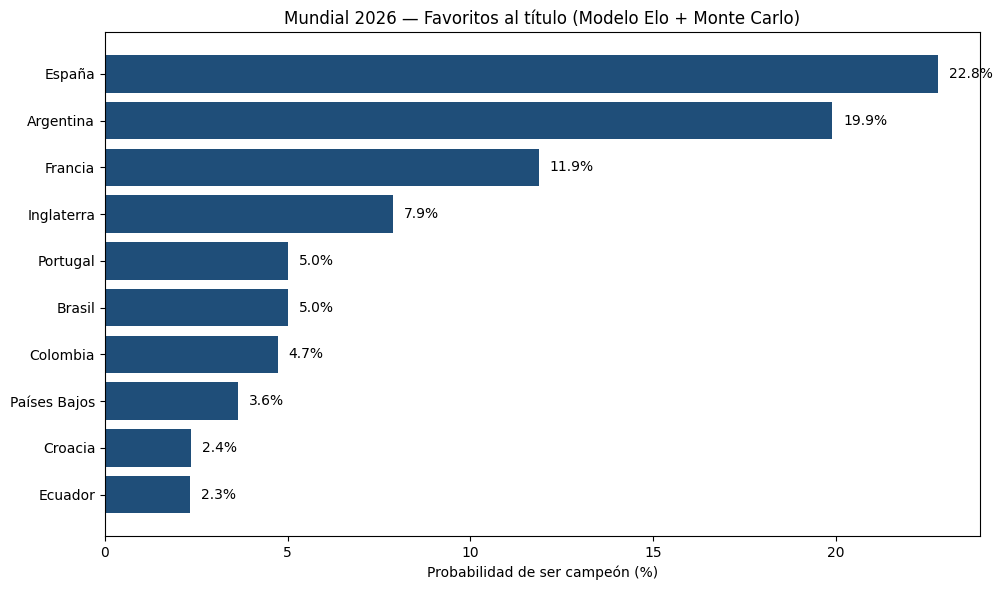

In [12]:
top_campeon = df.sort_values('Campeón %', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_campeon['Selección'][::-1], top_campeon['Campeón %'][::-1], color='#1f4e79')
plt.xlabel('Probabilidad de ser campeón (%)')
plt.title('Mundial 2026 — Favoritos al título (Modelo Elo + Monte Carlo)')
plt.tight_layout()
for i, v in enumerate(top_campeon['Campeón %'][::-1]):
    plt.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.show()